# Uploading **CSV**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Atlantic_South_Korea.csv')

df.head()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
0,18-05-2024,1,Like Crazy,Jimin,93,212241,single,6,False,https://i.scdn.co/image/ab67616d0000b2732b4607...
1,18-05-2024,2,UNFORGIVEN (feat. Nile Rodgers),LE SSERAFIM,87,182148,album,13,False,https://i.scdn.co/image/ab67616d0000b273d71fd7...
2,18-05-2024,3,Spicy,aespa,81,197040,single,6,False,https://i.scdn.co/image/ab67616d0000b27304878a...
3,18-05-2024,4,I AM,IVE,89,183853,album,11,False,https://i.scdn.co/image/ab67616d0000b27325ef3c...
4,18-05-2024,5,Queencard,(G)I-DLE,71,161240,single,6,False,https://i.scdn.co/image/ab67616d0000b27382dd24...


Checking the size:
We are checking

number of rows
number of columns
data types
missing values
duplicate records
date range
unique songs
unique artists

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.info()
df.describe(include='all')

Rows: 27800
Columns: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27800 entries, 0 to 27799
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             27800 non-null  object
 1   position         27800 non-null  int64 
 2   song             27800 non-null  object
 3   artist           27800 non-null  object
 4   popularity       27800 non-null  int64 
 5   duration_ms      27800 non-null  int64 
 6   album_type       27800 non-null  object
 7   total_tracks     27800 non-null  int64 
 8   is_explicit      27800 non-null  bool  
 9   album_cover_url  27800 non-null  object
dtypes: bool(1), int64(4), object(5)
memory usage: 1.9+ MB


,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
count,27800,27800.000000,27800,27800,27800.000000,27800.000000,27800,27800.000000,27800,27800
unique,555,NaN,527,194,NaN,NaN,3,NaN,2,394
top,01-03-2025,NaN,Like Crazy,Lim Young Woong,NaN,NaN,single,NaN,False,https://i.scdn.co/image/ab67616d0000b2738f116e...
freq,100,NaN,555,4804,NaN,NaN,17950,NaN,25145,2174
mean,NaN,25.500000,NaN,NaN,76.927446,191780.020468,NaN,5.894640,NaN,NaN
std,NaN,14.431129,NaN,NaN,12.907857,35611.039130,NaN,4.674461,NaN,NaN
min,NaN,1.000000,NaN,NaN,0.000000,36226.000000,NaN,1.000000,NaN,NaN
25%,NaN,13.000000,NaN,NaN,67.000000,170386.000000,NaN,2.000000,NaN,NaN
50%,NaN,25.500000,NaN,NaN,79.000000,188498.000000,NaN,6.000000,NaN,NaN
75%,NaN,38.000000,NaN,NaN,86.000000,212253.000000,NaN,10.000000,NaN,NaN


Checking missing values

In [ ]:
df.isnull().sum()

,0
date,0
position,0
song,0
artist,0
popularity,0
duration_ms,0
album_type,0
total_tracks,0
is_explicit,0
album_cover_url,0


Checking duplicates

In [ ]:
df.duplicated().sum()

np.int64(16)

Normalizing song and artist should not be treated as different songs

In [ ]:
df['song'] = df['song'].astype(str).str.strip()
df['artist'] = df['artist'].astype(str).str.strip()

df['song_artist'] = (
    df['song'].str.lower() + " | " +
    df['artist'].str.lower()
)

# **Converting duration**

Converting into minutes:

In [ ]:
df['duration_min'] = df['duration_ms'] / 60000

# **Validate 50 songs per day**

In [ ]:
daily_count = df.groupby('date').size()

daily_count.value_counts()

,count
50,554
100,1


In [ ]:
daily_count[daily_count != 50]

,0
date,
01-03-2025,100


In [ ]:
daily_count.sort_values().head(10)

,0
date,
21-09-2024,50
21-05-2024,50
21-05-2025,50
21-06-2024,50
21-06-2025,50
21-07-2024,50
21-07-2025,50
21-08-2024,50
21-08-2025,50


# **CHART RE-ENTRY DETECTION**

In [ ]:
df = df.sort_values(['song_artist', 'date'])

In [ ]:
df['previous_date'] = (
    df.groupby('song_artist')['date'].shift(1)
)
df.head(10)

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url,song_artist,duration_min,previous_date
23425,01-09-2025,26,1-800-hot-n-fun,LE SSERAFIM,64,173431,single,5,False,https://i.scdn.co/image/ab67616d0000b273485623...,1-800-hot-n-fun | le sserafim,2.890517,NaN
23477,02-09-2025,28,1-800-hot-n-fun,LE SSERAFIM,68,173431,single,5,False,https://i.scdn.co/image/ab67616d0000b273485623...,1-800-hot-n-fun | le sserafim,2.890517,01-09-2025
23527,03-09-2025,28,1-800-hot-n-fun,LE SSERAFIM,70,173431,single,5,False,https://i.scdn.co/image/ab67616d0000b273485623...,1-800-hot-n-fun | le sserafim,2.890517,02-09-2025
23581,04-09-2025,32,1-800-hot-n-fun,LE SSERAFIM,72,173431,single,5,False,https://i.scdn.co/image/ab67616d0000b273485623...,1-800-hot-n-fun | le sserafim,2.890517,03-09-2025
23644,05-09-2025,45,1-800-hot-n-fun,LE SSERAFIM,73,173431,single,5,False,https://i.scdn.co/image/ab67616d0000b273485623...,1-800-hot-n-fun | le sserafim,2.890517,04-09-2025
23694,06-09-2025,45,1-800-hot-n-fun,LE SSERAFIM,73,173431,single,5,False,https://i.scdn.co/image/ab67616d0000b273485623...,1-800-hot-n-fun | le sserafim,2.890517,05-09-2025
23748,07-09-2025,49,1-800-hot-n-fun,LE SSERAFIM,74,173431,single,5,False,https://i.scdn.co/image/ab67616d0000b273485623...,1-800-hot-n-fun | le sserafim,2.890517,06-09-2025
23798,08-09-2025,49,1-800-hot-n-fun,LE SSERAFIM,75,173431,single,5,False,https://i.scdn.co/image/ab67616d0000b273485623...,1-800-hot-n-fun | le sserafim,2.890517,07-09-2025
18625,26-05-2025,26,24YB (Intro),YANGHONGWON,38,83240,album,8,False,https://i.scdn.co/image/ab67616d0000b273e6afca...,24yb (intro) | yanghongwon,1.387333,NaN
18677,27-05-2025,28,24YB (Intro),YANGHONGWON,42,83240,album,8,False,https://i.scdn.co/image/ab67616d0000b273e6afca...,24yb (intro) | yanghongwon,1.387333,26-05-2025


# **Detecting exits and re-entries**

In [ ]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
df['previous_date'] = pd.to_datetime(df['previous_date'], format='%d-%m-%Y')
df['days_since_previous'] = (
    df['date'] - df['previous_date']
).dt.days

In [ ]:
df['new_run'] = (
    df['previous_date'].isna() |
    (df['days_since_previous'] > 1)
)

In [ ]:
df['run_number'] = (
    df.groupby('song_artist')['new_run']
      .cumsum()
)

In [ ]:
df[['song_artist', 'date', 'position', 'run_number']].head(20)

,song_artist,date,position,run_number
23425,1-800-hot-n-fun | le sserafim,2025-09-01,26,1
23477,1-800-hot-n-fun | le sserafim,2025-09-02,28,1
23527,1-800-hot-n-fun | le sserafim,2025-09-03,28,1
23581,1-800-hot-n-fun | le sserafim,2025-09-04,32,1
23644,1-800-hot-n-fun | le sserafim,2025-09-05,45,1
23694,1-800-hot-n-fun | le sserafim,2025-09-06,45,1
23748,1-800-hot-n-fun | le sserafim,2025-09-07,49,1
23798,1-800-hot-n-fun | le sserafim,2025-09-08,49,1
18625,24yb (intro) | yanghongwon,2025-05-26,26,1
18677,24yb (intro) | yanghongwon,2025-05-27,28,1


# **Creating the re-entry table**

In [ ]:
runs = (
    df.groupby(['song_artist', 'run_number'])
      .agg(
          start_date=('date', 'min'),
          end_date=('date', 'max'),
          retention_days=('date', 'nunique'),
          start_rank=('position', 'first'),
          best_rank=('position', 'min'),
          start_popularity=('popularity', 'first'),
          peak_popularity=('popularity', 'max'),
          song=('song', 'first'),
          artist=('artist', 'first'),
          album_type=('album_type', 'first'),
          total_tracks=('total_tracks', 'first'),
          is_explicit=('is_explicit', 'first'),
          duration_ms=('duration_ms', 'first')
      )
      .reset_index()
)

In [ ]:
runs['is_reentry'] = runs['run_number'] > 1

In [ ]:
reentries = runs[runs['is_reentry']].copy()

# **Calculating re-entry gap**

In [ ]:
reentries['previous_end_date'] = (
    reentries.groupby('song_artist')['end_date'].shift(1)
)

In [ ]:
reentries['reentry_gap_days'] = (
    reentries['start_date'] -
    reentries['previous_end_date']
).dt.days - 1

# **MOMENTUM ANALYSIS**

Calculating rank jump

In [ ]:
reentries['previous_end_rank'] = (
    reentries.groupby('song_artist')['best_rank'].shift(1)
)

In [ ]:
reentries['rank_jump'] = (
    reentries['previous_end_rank'] -
    reentries['start_rank']
)

# **Calculating days to peak**

In [ ]:
best_rank_date = (
    df.loc[df.groupby(['song_artist', 'run_number'])['position'].idxmin(),
           ['song_artist', 'run_number', 'date']]
    .rename(columns={'date': 'best_rank_date'})
)

reentries = reentries.merge(
    best_rank_date,
    on=['song_artist', 'run_number'],
    how='left'
)

In [ ]:
reentries['days_to_best_rank'] = (
    reentries['best_rank_date'] -
    reentries['start_date']
).dt.days

Calculating popularity change

In [ ]:
reentries['previous_end_popularity'] = (
    reentries.groupby('song_artist')['peak_popularity'].shift(1)
)

In [ ]:
reentries['popularity_change'] = (
    reentries['start_popularity'] -
    reentries['previous_end_popularity']
)

# **MOMENTUM SPIKE SCORE**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

reentries[
    ['rank_jump_norm',
     'popularity_change_norm',
     'retention_norm']
] = scaler.fit_transform(
    reentries[
        ['rank_jump',
         'popularity_change',
         'retention_days']
    ]
)

In [ ]:
reentries['recovery_norm'] = (
    1 - MinMaxScaler().fit_transform(
        reentries[['days_to_best_rank']]
    ).flatten()
)

In [ ]:
reentries['momentum_spike_score'] = (
    0.40 * reentries['rank_jump_norm'] +
    0.20 * reentries['popularity_change_norm'] +
    0.20 * reentries['recovery_norm'] +
    0.20 * reentries['retention_norm']
) * 100

# **FANDOM INTENSITY**

In [ ]:
fandom = (
    reentries.groupby(['song_artist', 'song', 'artist'])
    .agg(
        reentry_frequency=('run_number', 'count'),
        avg_rank_jump=('rank_jump', 'mean'),
        avg_recovery_speed=('days_to_best_rank', 'mean'),
        avg_retention=('retention_days', 'mean'),
        avg_momentum=('momentum_spike_score', 'mean')
    )
    .reset_index()
)

In [ ]:
fandom['frequency_score'] = (
    fandom['reentry_frequency'].rank(pct=True) * 100
)

fandom['rank_recovery_score'] = (
    fandom['avg_rank_jump'].rank(pct=True) * 100
)

fandom['speed_score'] = (
    (1 - fandom['avg_recovery_speed'].rank(pct=True)) * 100
)

fandom['retention_score'] = (
    fandom['avg_retention'].rank(pct=True) * 100
)

In [ ]:
fandom['fandom_intensity_score'] = (
    0.40 * fandom['frequency_score'] +
    0.30 * fandom['rank_recovery_score'] +
    0.20 * fandom['speed_score'] +
    0.10 * fandom['retention_score']
)

In [ ]:
fandom.sort_values(
    'fandom_intensity_score',
    ascending=False
).head(20)

,song_artist,song,artist,reentry_frequency,avg_rank_jump,avg_recovery_speed,avg_retention,avg_momentum,frequency_score,rank_recovery_score,speed_score,retention_score,fandom_intensity_score
216,standing next to you | jung kook,Standing Next to You,Jung Kook,328,-0.975535,0.000000,1.167683,51.960205,95.373665,88.444444,80.071174,9.608541,81.657888
1,3d (feat. jack harlow) | jung kook,3D (feat. Jack Harlow),Jung Kook,277,-0.771739,0.000000,1.108303,52.049672,93.238434,89.777778,80.071174,6.405694,80.883511
42,closer than this | jimin,Closer Than This,Jimin,303,-1.337748,0.000000,1.102310,51.633794,94.306050,84.444444,80.071174,6.049822,79.674970
174,perfect night | le sserafim,Perfect Night,LE SSERAFIM,245,-3.155738,0.000000,1.126531,50.929038,92.526690,68.000000,80.071174,6.761566,74.101068
193,seven (feat. latto) (explicit ver.) | jung kook,Seven (feat. Latto) (Explicit Ver.),Jung Kook,329,-0.371951,5.075988,1.167173,52.012745,95.907473,93.333333,30.960854,9.252669,73.480427
2,3d (feat. jack harlow) | jung kook & jack harlow,3D (feat. Jack Harlow),Jung Kook & Jack Harlow,80,-1.455696,0.000000,1.375000,51.958382,74.377224,82.666667,80.071174,28.113879,73.376512
150,magnetic | illit,Magnetic,ILLIT,213,-3.599057,0.000000,1.140845,50.719010,91.103203,65.333333,80.071174,7.117438,72.767260
205,smeraldo garden marching band (feat. loco) | j...,Smeraldo Garden Marching Band (feat. Loco),Jimin,98,-2.061856,0.000000,1.306122,51.431486,78.825623,76.000000,80.071174,23.309609,72.675445
11,"angel pt. 1 (feat. jimin of bts, jvke & muni l...","Angel Pt. 1 (feat. Jimin of BTS, JVKE & Muni L...",Fast & Furious: The Fast Saga & Jimin & BTS,186,-3.535135,0.000000,1.161290,50.675771,89.679715,66.222222,80.071174,8.540925,72.606880
62,drama | aespa,Drama,aespa,191,-3.836842,0.000000,1.162304,50.652247,90.035587,63.555556,80.071174,8.896797,71.984816


# **CONTENT ANALYSIS**

In [ ]:
reentries.groupby('album_type').agg(
    reentries=('song_artist','count'),
    avg_momentum=('momentum_spike_score','mean'),
    avg_rank_jump=('rank_jump','mean'),
    avg_retention=('retention_days','mean'),
    avg_recovery=('days_to_best_rank','mean')
)

,reentries,avg_momentum,avg_rank_jump,avg_retention,avg_recovery
album_type,,,,,
album,6579,50.036160,-3.743823,1.393677,12.948472
single,11342,48.476711,-6.624720,1.437577,14.853730


# **Album size**

In [ ]:
reentries.groupby('total_tracks')['momentum_spike_score'].mean()

,momentum_spike_score
total_tracks,
1,48.871740
2,48.262479
3,49.318601
4,48.565576
5,48.143954
6,48.261498
7,50.764626
8,48.164934
9,47.728262


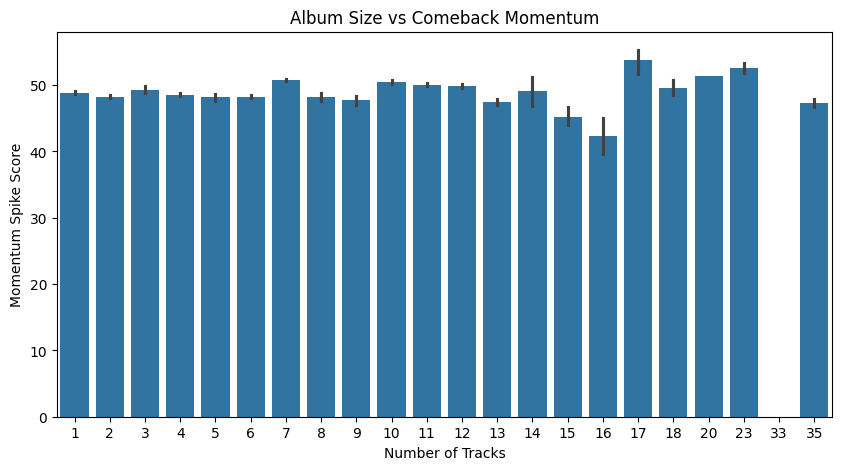

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=reentries,
    x='total_tracks',
    y='momentum_spike_score'
)

plt.title('Album Size vs Comeback Momentum')
plt.xlabel('Number of Tracks')
plt.ylabel('Momentum Spike Score')

plt.show()

# **Explicit vs Clean**

In [ ]:
reentries.groupby('is_explicit').agg(
    reentries=('song_artist','count'),
    avg_momentum=('momentum_spike_score','mean'),
    avg_rank_jump=('rank_jump','mean'),
    avg_retention=('retention_days','mean'),
    avg_recovery=('days_to_best_rank','mean')
)

,reentries,avg_momentum,avg_rank_jump,avg_retention,avg_recovery
is_explicit,,,,,
False,16159,48.899628,-5.848969,1.432514,14.509561
True,1762,50.418518,-2.986759,1.320091,10.896141
